In [35]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report
import joblib

In [36]:
dt=pd.read_csv("weather_classification_data.csv")
dt.head()

,temperature,humidity,wind_speed,precipitation (%),cloud_cover,atmospheric_pressure,uv_index,season,visibility (km),location,weather_type
0,14,73,9.5,82,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39,96,8.5,71,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30,64,7.0,16,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38,83,1.5,82,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27,74,17.0,66,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [37]:
print(dt.weather_type)

0         Rainy
1        Cloudy
2         Sunny
3         Sunny
4         Rainy
          ...  
13195     Rainy
13196     Snowy
13197    Cloudy
13198     Snowy
13199     Rainy
Name: weather_type, Length: 13200, dtype: object


In [3]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   temperature           13200 non-null  int64  
 1   humidity              13200 non-null  int64  
 2   wind_speed            13200 non-null  float64
 3   precipitation (%)     13200 non-null  int64  
 4   cloud_cover           13200 non-null  object 
 5   atmospheric_pressure  13200 non-null  float64
 6   uv_index              13200 non-null  int64  
 7   season                13200 non-null  object 
 8   visibility (km)       13200 non-null  float64
 9   location              13200 non-null  object 
 10  weather_type          13200 non-null  object 
dtypes: float64(3), int64(4), object(4)
memory usage: 1.1+ MB


In [4]:
dt.isnull().sum()

temperature             0
humidity                0
wind_speed              0
precipitation (%)       0
cloud_cover             0
atmospheric_pressure    0
uv_index                0
season                  0
visibility (km)         0
location                0
weather_type            0
dtype: int64

In [6]:
dt.describe()

,temperature,humidity,wind_speed,precipitation (%),atmospheric_pressure,uv_index,visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [9]:
label_encoders = {}
for col in dt.columns:
    if dt[col].dtype == "object":
        le = LabelEncoder()
        dt[col] = le.fit_transform(dt[col])
        label_encoders[col] = le

In [10]:
dt.head()

,temperature,humidity,wind_speed,precipitation (%),cloud_cover,atmospheric_pressure,uv_index,season,visibility (km),location,weather_type
0,14,73,9.5,82,3,1010.82,2,3,3.5,1,1
1,39,96,8.5,71,3,1011.43,7,1,10.0,1,0
2,30,64,7.0,16,0,1018.72,5,1,5.5,2,3
3,38,83,1.5,82,0,1026.25,7,1,1.0,0,3
4,27,74,17.0,66,2,990.67,1,3,2.5,2,1


In [14]:
dt.corr()

,temperature,humidity,wind_speed,precipitation (%),cloud_cover,atmospheric_pressure,uv_index,season,visibility (km),location,weather_type
temperature,1.000000,-0.207969,-0.070022,-0.287206,-0.224642,0.209188,0.374773,-0.377942,0.250751,-0.196108,0.028923
humidity,-0.207969,1.000000,0.406079,0.638631,0.277199,-0.120653,-0.342694,0.189145,-0.479969,0.079968,-0.250558
wind_speed,-0.070022,0.406079,1.000000,0.443770,0.183863,-0.077757,-0.068147,0.058676,-0.311828,0.014091,-0.166485
precipitation (%),-0.287206,0.638631,0.443770,1.000000,0.267368,-0.177444,-0.291601,0.210372,-0.457444,0.091911,-0.161578
cloud_cover,-0.224642,0.277199,0.183863,0.267368,1.000000,-0.096133,-0.347301,0.076947,-0.169604,0.030464,-0.536681
atmospheric_pressure,0.209188,-0.120653,-0.077757,-0.177444,-0.096133,1.000000,0.154128,-0.126795,0.120182,-0.077053,0.030679
uv_index,0.374773,-0.342694,-0.068147,-0.291601,-0.347301,0.154128,1.000000,-0.201870,0.362922,-0.100510,0.345804
season,-0.377942,0.189145,0.058676,0.210372,0.076947,-0.126795,-0.201870,1.000000,-0.231691,0.147115,0.118791
visibility (km),0.250751,-0.479969,-0.311828,-0.457444,-0.169604,0.120182,0.362922,-0.231691,1.000000,-0.093642,0.047448
location,-0.196108,0.079968,0.014091,0.091911,0.030464,-0.077053,-0.100510,0.147115,-0.093642,1.000000,0.071665


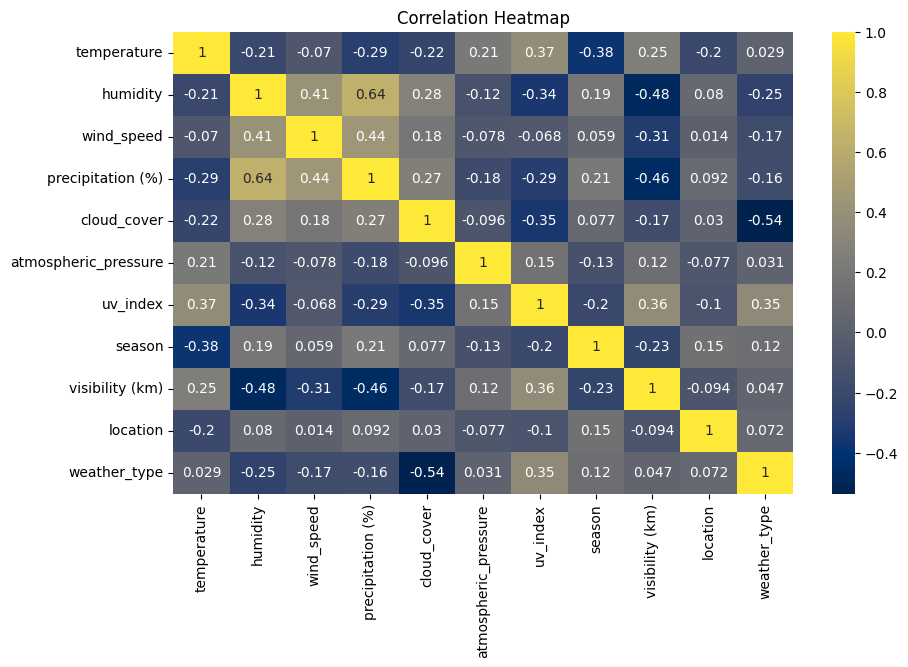

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(dt.corr(), annot=True, cmap="cividis")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
x= dt.drop(columns=["weather_type"])
y = dt["weather_type"]

In [20]:
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(score_func=f_classif, k=7)
selector.fit(x, y)
selected_features = x.columns[selector.get_support()]
print("Selected Features:")
print(selected_features)

Selected Features:
Index(['temperature', 'humidity', 'precipitation (%)', 'cloud_cover',
       'uv_index', 'season', 'visibility (km)'],
      dtype='object')


In [21]:
x_selected=x[selected_features]
print(x_selected)

       temperature  humidity  precipitation (%)  cloud_cover  uv_index  \
0               14        73                 82            3         2   
1               39        96                 71            3         7   
2               30        64                 16            0         5   
3               38        83                 82            0         7   
4               27        74                 66            2         1   
...            ...       ...                ...          ...       ...   
13195           10        74                 71            2         1   
13196           -1        76                 23            1         1   
13197           30        77                 28            2         3   
13198            3        76                 94            2         0   
13199           -5        38                 92            2         5   

       season  visibility (km)  
0           3              3.5  
1           1             10.0  
2           

In [22]:
X_train, X_test, y_train, y_test = train_test_split(x_selected, y, test_size=0.2, random_state=42)

In [23]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(10560, 7)
(2640, 7)
(10560,)
(2640,)


In [25]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(random_state=42))
])

In [27]:
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2


In [28]:
pred = pipeline.predict(X_test)

In [29]:
acc = accuracy_score(y_test, pred)
report=classification_report(y_test,pred)
print("Model Accuracy:", acc)
print("Classification Report:\n",report)

Model Accuracy: 0.8924242424242425
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.87      0.85       651
           1       0.89      0.88      0.88       647
           2       0.92      0.95      0.93       701
           3       0.92      0.87      0.90       641

    accuracy                           0.89      2640
   macro avg       0.89      0.89      0.89      2640
weighted avg       0.89      0.89      0.89      2640



In [30]:
joblib.dump(pipeline, "weather_pipeline_model.pkl")
joblib.dump(label_encoders, "weather_label_encoders.pkl")
print("Model Developed Successfully")

Model Developed Successfully


In [31]:
print(pipeline.feature_names_in_)

['temperature' 'humidity' 'precipitation (%)' 'cloud_cover' 'uv_index'
 'season' 'visibility (km)']
